<div>
Olá, Cida!

Meu nome é Luiz. Fico feliz em revisar seu projeto. Ao longo do texto farei algumas observações sobre melhorias no código e também farei comentários sobre suas percepções sobre o assunto. Estarei aberto a feedbacks e discussões sobre o tema.

**Peço que mantenha e não altere os comentários que eu fizer por aqui para que possamos nos localizar posteriormente, ok?**

Mais uma coisa, vamos utilizar um código de cores para você entender o meu feedback no seu notebook. Funciona assim:

<div class="alert alert-block alert-success">
<b> Comentário do revisor: </b> <a class="tocSkip"></a>

Sucesso. Tudo foi feito corretamente.
</div>

<div class="alert alert-block alert-warning">
<b>Comentário do revisor: </b> <a class="tocSkip"></a>

Alerta não crítico, mas que pode ser corrigido para melhoria geral no seu código/análise.
</div>

<div class="alert alert-block alert-danger">

<b>Comentário do revisor: </b> <a class="tocSkip"></a>
    
Erro que precisa ser arrumado, caso contrário seu projeto **não** será aceito.
</div>

Você pode interagir comigo através dessa célula:
<div class="alert alert-block alert-info">
<b>Resposta do Aluno.</b> <a class="tocSkip"></a>
</div>

<div class="alert alert-block alert-success">
<b> Comentário do revisor: </b> <a class="tocSkip"></a>

Obrigado por enviar o seu projeto e pelo esforço de chegar até aqui. O seu trabalho ficou excelente e gostaria de destacar alguns pontos fortes:
    
- Código bem simples e estruturado usando funções
- Comentários sucintos e bem objetivos
- Usou variação muito rica de gráficos
- Calculou estatísticas e apresentou conclusões em cada seção
    
Deixei algumas sugestões em seu projeto, mas não são mandatórias. Você implementou as etapas necessárias para aprovação, mas leve essas sugestões como possíveis melhorias para projetos futuros.


Espero que você tenha uma jornada de muito aprendizado e te de desejo muito sucesso.
    
<br>
    
**Até breve!**

</div>

# Projeto Integrado — Sprint 6

## Análise de Dados de Jogos Eletrônicos

Neste projeto, realizarei uma análise de dados da loja online Ice, especializada na venda de videogames em diferentes regiões do mundo. O conjunto de dados contém informações sobre vendas, plataformas, gêneros, avaliações de usuários e críticos, além das classificações ESRB dos jogos.

O principal objetivo da análise é identificar padrões que indiquem o sucesso de um jogo, permitindo reconhecer tendências de mercado e auxiliar no planejamento de campanhas publicitárias para o ano de 2017.

Ao longo do projeto, serão realizadas etapas de preparação e tratamento dos dados, análise exploratória, construção de visualizações gráficas, criação de perfis de usuários por região e testes de hipóteses estatísticas.

As análises serão desenvolvidas utilizando Python e bibliotecas como pandas, matplotlib e scipy.

In [165]:
# Importação das bibliotecas

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from scipy import stats

In [166]:
# Carregamento dos dados

df = pd.read_csv('/datasets/games.csv')

## Exploração inicial dos dados

Nesta etapa, realizarei uma análise inicial do conjunto de dados para compreender sua estrutura, identificar os tipos de dados presentes, verificarei possíveis valores ausentes e obterei uma visão geral das informações disponíveis.

In [167]:
# Visualização das primeiras linhas do dataset

df.head()

,Name,Platform,Year_of_Release,Genre,NA_sales,EU_sales,JP_sales,Other_sales,Critic_Score,User_Score,Rating
0,Wii Sports,Wii,2006.0,Sports,41.36,28.96,3.77,8.45,76.0,8,E
1,Super Mario Bros.,NES,1985.0,Platform,29.08,3.58,6.81,0.77,NaN,NaN,NaN
2,Mario Kart Wii,Wii,2008.0,Racing,15.68,12.76,3.79,3.29,82.0,8.3,E
3,Wii Sports Resort,Wii,2009.0,Sports,15.61,10.93,3.28,2.95,80.0,8,E
4,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,11.27,8.89,10.22,1.00,NaN,NaN,NaN


In [168]:
# Informações gerais sobre o dataset

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Name             16713 non-null  object 
 1   Platform         16715 non-null  object 
 2   Year_of_Release  16446 non-null  float64
 3   Genre            16713 non-null  object 
 4   NA_sales         16715 non-null  float64
 5   EU_sales         16715 non-null  float64
 6   JP_sales         16715 non-null  float64
 7   Other_sales      16715 non-null  float64
 8   Critic_Score     8137 non-null   float64
 9   User_Score       10014 non-null  object 
 10  Rating           9949 non-null   object 
dtypes: float64(6), object(5)
memory usage: 1.4+ MB


In [169]:
# Estatísticas descritivas das colunas numéricas

df.describe()

,Year_of_Release,NA_sales,EU_sales,JP_sales,Other_sales,Critic_Score
count,16446.000000,16715.000000,16715.000000,16715.000000,16715.000000,8137.000000
mean,2006.484616,0.263377,0.145060,0.077617,0.047342,68.967679
std,5.877050,0.813604,0.503339,0.308853,0.186731,13.938165
min,1980.000000,0.000000,0.000000,0.000000,0.000000,13.000000
25%,2003.000000,0.000000,0.000000,0.000000,0.000000,60.000000
50%,2007.000000,0.080000,0.020000,0.000000,0.010000,71.000000
75%,2010.000000,0.240000,0.110000,0.040000,0.030000,79.000000
max,2016.000000,41.360000,28.960000,10.220000,10.570000,98.000000


<div class="alert alert-block alert-success">
<b> Comentário do revisor: </b> <a class="tocSkip"></a>

- Os dados foram carregados corretamente
- O método `head()` foi utilizado para estudo inicial dos dados
</div>

## Preparação dos dados

Aqui, preparareios dados para análise. Serão realizados ajustes nos nomes das colunas, conversão de tipos de dados, tratamento de valores ausentes e criação de novas variáveis necessárias para o desenvolvimento do projeto.

In [170]:
# Padronização dos nomes das colunas

df.columns = df.columns.str.lower()

In [171]:
# Verificando valores ausentes

df.isna().sum()

name                  2
platform              0
year_of_release     269
genre                 2
na_sales              0
eu_sales              0
jp_sales              0
other_sales           0
critic_score       8578
user_score         6701
rating             6766
dtype: int64

In [172]:
# Verificando tipos de dados

df.dtypes

name                object
platform            object
year_of_release    float64
genre               object
na_sales           float64
eu_sales           float64
jp_sales           float64
other_sales        float64
critic_score       float64
user_score          object
rating              object
dtype: object

In [173]:
# Conversão da coluna year_of_release para inteiro

df['year_of_release'] = df['year_of_release'].astype('Int64')

In [174]:
# Substituindo valores 'tbd' por NaN na coluna user_score

df['user_score'] = df['user_score'].replace('tbd', np.nan)

In [175]:
# Convertendo user_score para float

df['user_score'] = df['user_score'].astype(float)

### Ajustes nos tipos de dados

Converti a coluna `year_of_release` para o tipo inteiro para facilitar análises relacionadas ao período de lançamento dos jogos.

Encontrei na coluna `user_score`, valores `"tbd"` ("to be determined"), indicando assim que algumas avaliações dos usuários ainda não haviam sido definidas no momento da coleta dos dados. Esses valores foram substituídos por `NaN` para permitir a conversão da coluna para o tipo numérico (`float`), possibilitando análises estatísticas e cálculos de correlação.

Essas alterações foram necessárias para garantir maior consistência e precisão nas análises realizadas ao longo do projeto.

In [176]:
# Criação da coluna de vendas globais

df['total_sales'] = (
    df['na_sales']
    + df['eu_sales']
    + df['jp_sales']
    + df['other_sales']
)

<div class="alert alert-block alert-success">
<b> Comentário do revisor: </b> <a class="tocSkip"></a>
    
- A receita total foi calculada e um novo atributo foi criado (`total_sales`)
- Os tipos de dados foram convertidos corretamente.
</div>

In [177]:
# Verificando o resultado

df.head()

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating,total_sales
0,Wii Sports,Wii,2006,Sports,41.36,28.96,3.77,8.45,76.0,8.0,E,82.54
1,Super Mario Bros.,NES,1985,Platform,29.08,3.58,6.81,0.77,NaN,NaN,NaN,40.24
2,Mario Kart Wii,Wii,2008,Racing,15.68,12.76,3.79,3.29,82.0,8.3,E,35.52
3,Wii Sports Resort,Wii,2009,Sports,15.61,10.93,3.28,2.95,80.0,8.0,E,32.77
4,Pokemon Red/Pokemon Blue,GB,1996,Role-Playing,11.27,8.89,10.22,1.00,NaN,NaN,NaN,31.38


# Análise exploratória dos dados

Serão analisados nessa etapa, padrões e tendências do mercado de jogos eletrônicos ao longo dos anos. O objetivo é identificar plataformas, gêneros e características associadas ao sucesso comercial dos jogos, além de compreender o comportamento das vendas em diferentes períodos.

### Quantidade de jogos lançados por ano

Primeiro, analisarei a quantidade de jogos lançados ao longo dos anos para identificar possíveis tendências de crescimento ou queda da indústria.

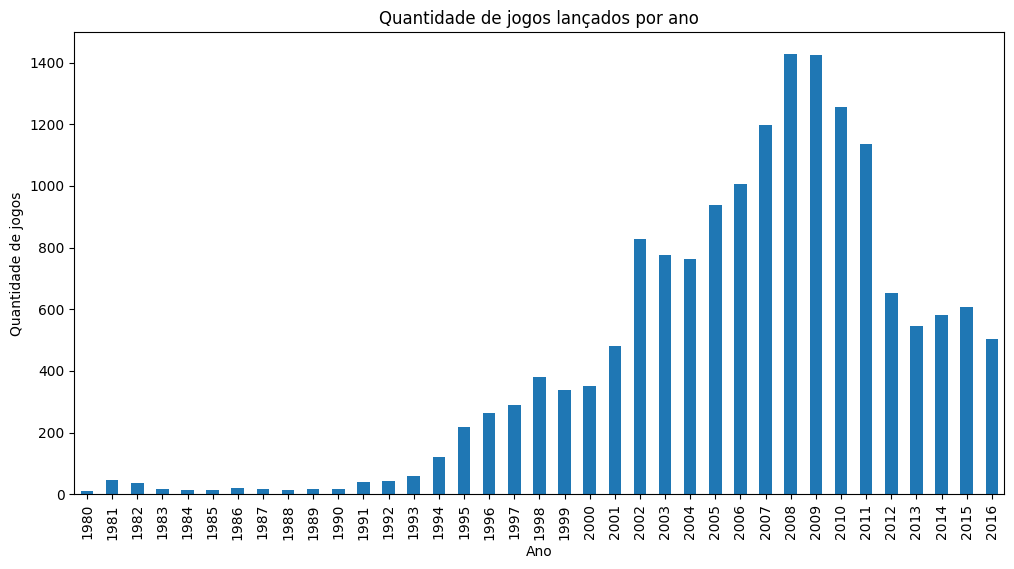

In [178]:
# Quantidade de jogos lançados por ano

games_per_year = (
    df.groupby('year_of_release')['name']
    .count()
)

games_per_year.plot(
    kind='bar',
    figsize=(12,6)
)

plt.title('Quantidade de jogos lançados por ano')
plt.xlabel('Ano')
plt.ylabel('Quantidade de jogos')

plt.show()

Segundo o gráfico, percebe se que a quantidade de jogos lançados por ano cresceu gradualmente ao longo das décadas de 1980 e 1990, apresentando um aumento mais acelerado a partir dos anos 2000. O pico de lançamentos ocorreu entre 2008 e 2009, período em que a indústria de jogos aparenta ter alcançado um dos seus momentos de maior expansão.

Após 2010, percebe-se uma redução gradual no número de jogos lançados. Essa queda pode estar relacionada à transição entre gerações de consoles, ao aumento da complexidade e do custo de desenvolvimento dos jogos e à maior concentração do mercado em títulos de grande orçamento.

Os dados mais recentes, especialmente de 2016, podem estar incompletos, conforme indicado na descrição do projeto, o que também pode contribuir para a redução observada nos últimos anos.

<div class="alert alert-block alert-success">
<b> Comentário do revisor: </b> <a class="tocSkip"></a>
    
- A distribuição dos lançamentos foi analisada corretamente!
</div>

### Análise das vendas por plataforma

Agora, com o objetivo de identificar quais consoles tiveram maior volume de vendas, quais perderam relevância com o tempo e quais plataformas apresentam potencial de crescimento, analisarei o desempenho das plataformas ao longo dos anos,

In [179]:
# Vendas globais por plataforma

platform_sales = (
    df.groupby('platform')['total_sales']
    .sum()
    .sort_values(ascending=False)
)

platform_sales

platform
PS2     1255.77
X360     971.42
PS3      939.65
Wii      907.51
DS       806.12
PS       730.86
GBA      317.85
PS4      314.14
PSP      294.05
PC       259.52
3DS      259.00
XB       257.74
GB       255.46
NES      251.05
N64      218.68
SNES     200.04
GC       198.93
XOne     159.32
2600      96.98
WiiU      82.19
PSV       54.07
SAT       33.59
GEN       30.77
DC        15.95
SCD        1.86
NG         1.44
WS         1.42
TG16       0.16
3DO        0.10
GG         0.04
PCFX       0.03
Name: total_sales, dtype: float64

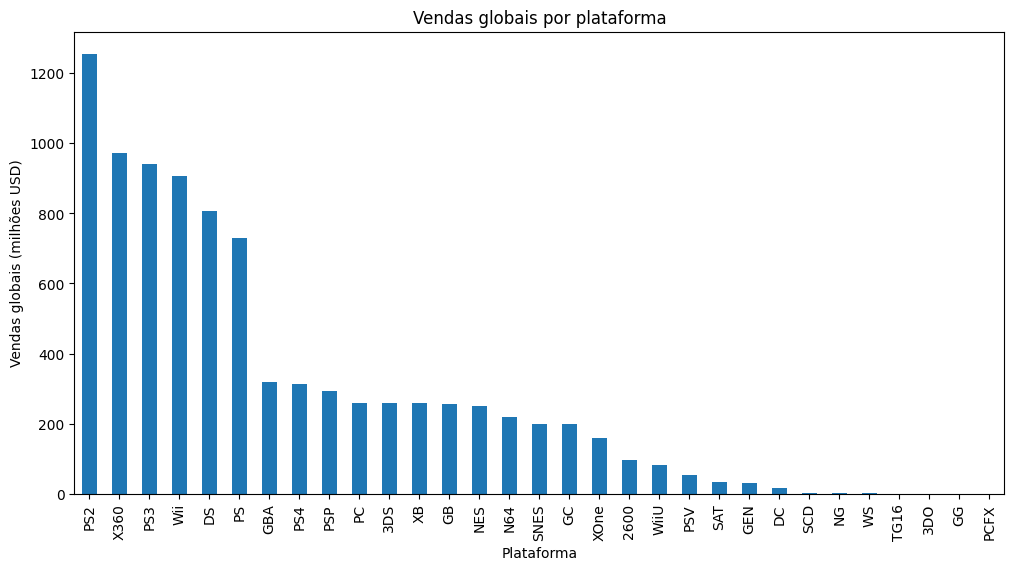

In [180]:
# Gráfico das plataformas com maiores vendas globais

platform_sales.plot(
    kind='bar',
    figsize=(12,6)
)

plt.title('Vendas globais por plataforma')
plt.xlabel('Plataforma')
plt.ylabel('Vendas globais (milhões USD)')

plt.show()

Nota-se que as plataformas com maiores vendas globais foram PS2, Xbox 360, PS3, Wii e DS, indicando que esses consoles dominaram o mercado em diferentes períodos da indústria de jogos.

O PlayStation 2 apresenta o maior volume de vendas entre todas as plataformas, destacando seu enorme sucesso comercial e longa permanência no mercado. Plataformas como PS3 e Xbox 360 também demonstram forte desempenho, refletindo a popularização dos jogos online e o crescimento da indústria durante suas gerações.

Percebe-se ainda que muitas plataformas mais antigas apresentam vendas bastante reduzidas, indicando o ciclo natural de substituição tecnológica do mercado de consoles. Novas plataformas surgem, atingem um pico de popularidade e, posteriormente, perdem espaço para gerações mais recentes.

Além disso, plataformas mais recentes presentes nos dados, como PS4 e Xbox One, ainda demonstram potencial de crescimento, sendo importantes candidatas para análises voltadas ao planejamento de campanhas para 2017.

### Evolução das vendas das plataformas ao longo dos anos

Nesta etapa, será analisada a evolução das vendas das principais plataformas ao longo do tempo. O objetivo é identificar o ciclo de vida dos consoles, observar períodos de crescimento e queda e compreender quanto tempo, em média, uma plataforma permanece relevante no mercado.

In [181]:
# Selecionando as plataformas com maiores vendas globais

top_platforms = (
    df.groupby('platform')['total_sales']
    .sum()
    .sort_values(ascending=False)
    .head(6)
    .index
)

top_platforms

Index(['PS2', 'X360', 'PS3', 'Wii', 'DS', 'PS'], dtype='object', name='platform')

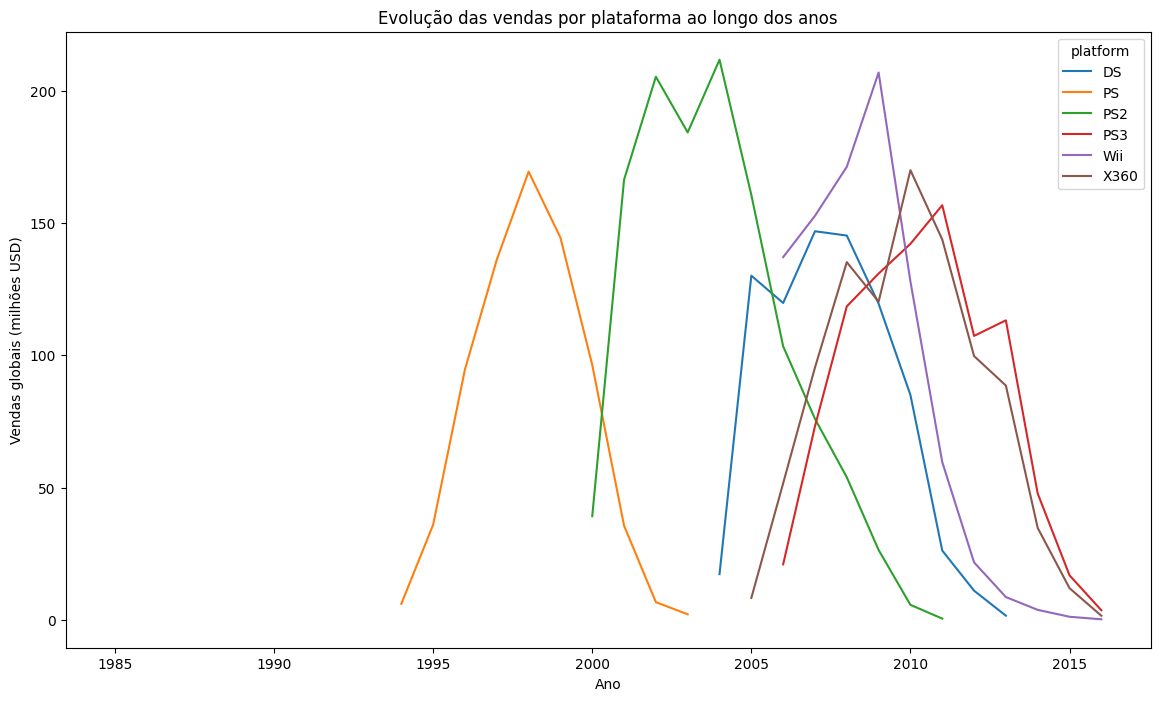

In [182]:
# Evolução das vendas por plataforma ao longo dos anos

platform_year_sales = (
    df[df['platform'].isin(top_platforms)]
    .pivot_table(
        index='year_of_release',
        columns='platform',
        values='total_sales',
        aggfunc='sum'
    )
)

platform_year_sales.plot(
    figsize=(14,8)
)

plt.title('Evolução das vendas por plataforma ao longo dos anos')
plt.xlabel('Ano')
plt.ylabel('Vendas globais (milhões USD)')

plt.show()

O gráfico mostra claramente o ciclo de vida das principais plataformas de videogame ao longo dos anos. Observa-se que cada console passa por um período de crescimento, atinge um pico de vendas e posteriormente entra em declínio até ser substituído por novas gerações.

Plataformas como PS2, Wii e DS apresentaram períodos de grande sucesso comercial, alcançando altos volumes de vendas globais em seus anos de maior popularidade. No entanto, após alguns anos, suas vendas diminuíram significativamente, evidenciando o processo natural de obsolescência tecnológica da indústria.

Também é possível perceber que, em média, uma plataforma permanece relevante no mercado por aproximadamente 8 a 10 anos, considerando desde o início do crescimento até a queda nas vendas.

Além disso, observa-se que plataformas mais recentes, como PS3 e Xbox 360, continuaram apresentando vendas relevantes por mais tempo, refletindo a evolução tecnológica e a ampliação do mercado de jogos eletrônicos.

Com base nessa análise, torna-se mais adequado utilizar dados mais recentes para construir previsões para 2017, já que plataformas antigas podem não representar o comportamento atual do mercado.

### Definição do período relevante para análise

Com base nas análises anteriores, utilizarei um período mais recente dos dados para construir previsões relacionadas ao ano de 2017. Isso é importante porque o mercado de videogames sofre mudanças rápidas, com novas plataformas surgindo e outras perdendo relevância ao longo do tempo.

In [183]:
# Selecionando apenas dados recentes

recent_df = df[df['year_of_release'] >= 2012]

recent_df.head()

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating,total_sales
16,Grand Theft Auto V,PS3,2013,Action,7.02,9.09,0.98,3.96,97.0,8.2,M,21.05
23,Grand Theft Auto V,X360,2013,Action,9.66,5.14,0.06,1.41,97.0,8.1,M,16.27
31,Call of Duty: Black Ops 3,PS4,2015,Shooter,6.03,5.86,0.36,2.38,NaN,NaN,NaN,14.63
33,Pokemon X/Pokemon Y,3DS,2013,Role-Playing,5.28,4.19,4.35,0.78,NaN,NaN,NaN,14.60
34,Call of Duty: Black Ops II,PS3,2012,Shooter,4.99,5.73,0.65,2.42,83.0,5.3,M,13.79


Escolhi o período a partir de 2012 por representar melhor o cenário mais recente da indústria de jogos. Como as plataformas possuem ciclos de vida relativamente curtos, utilizar dados muito antigos poderia distorcer as análises e prejudicar previsões relacionadas ao mercado de 2017.

In [184]:
# Vendas das plataformas no período recente

recent_platform_sales = (
    recent_df.groupby('platform')['total_sales']
    .sum()
    .sort_values(ascending=False)
)

recent_platform_sales

platform
PS4     314.14
PS3     288.79
X360    236.54
3DS     194.61
XOne    159.32
WiiU     82.19
PC       62.65
PSV      49.18
Wii      35.37
DS       12.55
PSP      11.19
Name: total_sales, dtype: float64

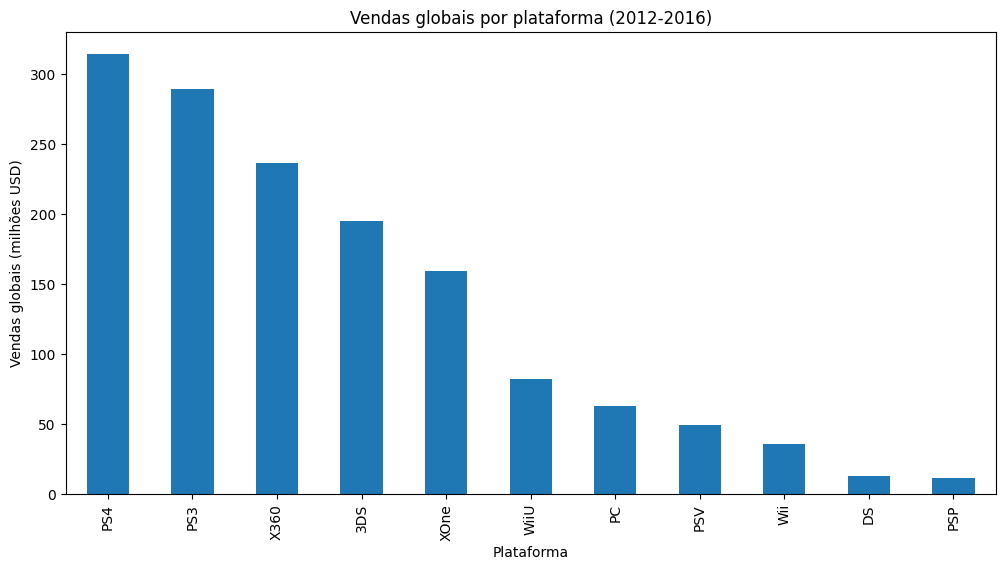

In [185]:
# Gráfico das vendas recentes por plataforma

recent_platform_sales.plot(
    kind='bar',
    figsize=(12,6)
)

plt.title('Vendas globais por plataforma (2012-2016)')
plt.xlabel('Plataforma')
plt.ylabel('Vendas globais (milhões USD)')

plt.show()

 Percebe-seque, no período entre 2012 e 2016, as plataformas PS4, PS3 e Xbox 360 lideraram as vendas globais de jogos, demonstrando forte presença no mercado durante os anos mais recentes analisados.

O PS4 apresenta o maior volume de vendas entre as plataformas do período, indicando grande potencial de mercado e forte relevância para campanhas publicitárias voltadas para 2017. O Xbox One também apresenta resultados expressivos, embora inferiores aos principais concorrentes da Sony.

Plataformas como Wii, DS e PSP demonstram queda significativa nas vendas, indicando perda de relevância e possível encerramento de seus ciclos de vida no mercado.

Além disso, nota-se que consoles mais recentes tendem a concentrar maior volume de vendas, reforçando a importância de utilizar dados atualizados para análises e previsões relacionadas à indústria de jogos eletrônicos.

### Distribuição das vendas globais por plataforma

Agora analisaremos a distribuição das vendas globais dos jogos em diferentes plataformas utilizando diagramas de caixa (boxplots). Essa análise permite observar a dispersão das vendas, identificar possíveis valores extremos e comparar o desempenho médio entre as plataformas.

Para melhorar a visualização do boxplot, ajustei o limite do eixo Y para valores entre 0 e 2 milhões de dólares em vendas globais. Apliquei essa limitação porque existem muitos valores extremos (outliers) com vendas muito altas, que dificultariam a visualização da distribuição da maior parte dos jogos.

<Figure size 1400x800 with 0 Axes>

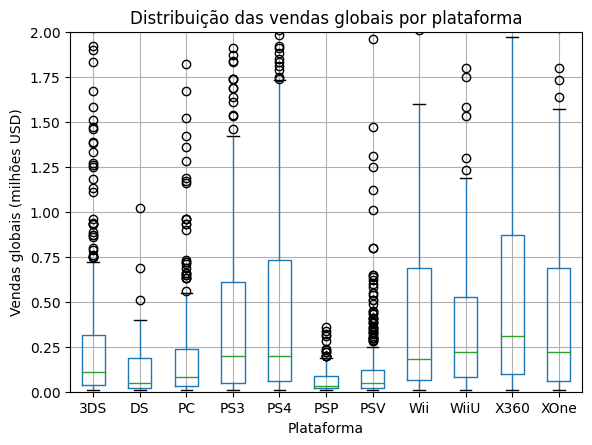

In [186]:
# Boxplot das vendas globais por plataforma

plt.figure(figsize=(14,8))

recent_df.boxplot(
    column='total_sales',
    by='platform'
)

plt.ylim(0, 2)

plt.title('Distribuição das vendas globais por plataforma')
plt.suptitle('')

plt.xlabel('Plataforma')
plt.ylabel('Vendas globais (milhões USD)')

plt.show()

Segundo o boxplot a distribuição das vendas varia significativamente entre as plataformas analisadas. Observa-se que plataformas como PS4, Xbox 360, XOne, Wii e PS3 apresentam medianas de vendas mais elevadas em comparação com plataformas portáteis como PSP, DS e PSV.

Também é possível perceber uma grande quantidade de outliers em praticamente todas as plataformas, indicando a existência de alguns jogos com vendas extremamente altas em relação à maioria dos títulos. Isso demonstra que poucos jogos concentram grande parte do sucesso comercial do mercado.

As plataformas PS4, Xbox 360 e XOne apresentam maior dispersão nas vendas, sugerindo uma variedade maior no desempenho comercial dos jogos lançados nesses consoles.

De modo geral, apesar de existirem diferenças nas vendas médias entre as plataformas, a maioria dos jogos apresenta vendas relativamente baixas, enquanto apenas alguns títulos alcançam grande sucesso global.

<div class="alert alert-block alert-success">
<b> Comentário do revisor: </b> <a class="tocSkip"></a>
    
- As distribuições de lançamentos e vendas por plataforma foram analisadas
- O ciclo de vida das plataformas foi estudado
</div>

### Relação entre avaliações e vendas

Nesta etapa, será analisado como as avaliações dos críticos e dos usuários influenciam as vendas globais dos jogos em uma das plataformas mais populares do período recente.

In [187]:
# Filtrando jogos da plataforma PS4

ps4 = recent_df[recent_df['platform'] == 'PS4']

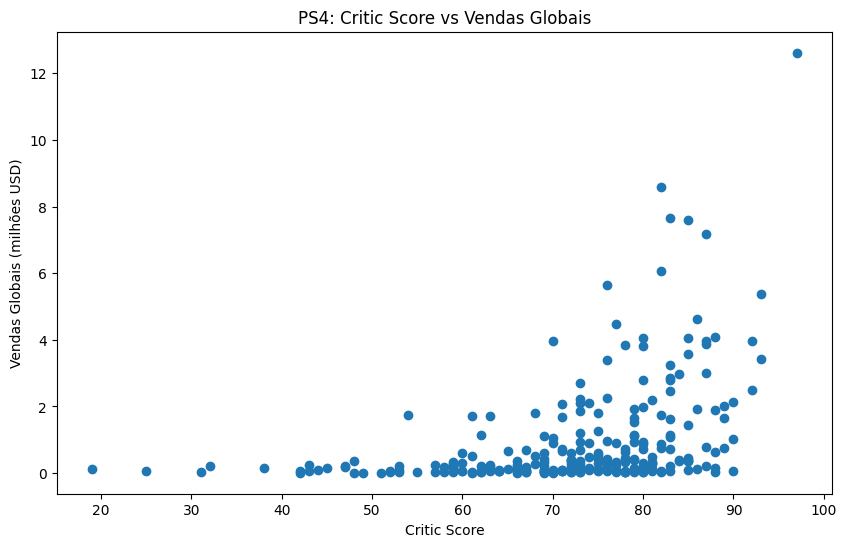

In [188]:
# Relação entre critic_score e vendas globais

plt.figure(figsize=(10,6))

plt.scatter(
    ps4['critic_score'],
    ps4['total_sales']
)

plt.title('PS4: Critic Score vs Vendas Globais')

plt.xlabel('Critic Score')
plt.ylabel('Vendas Globais (milhões USD)')

plt.show()

In [189]:
# Correlação entre critic_score e vendas globais

ps4[['critic_score', 'total_sales']].corr()

,critic_score,total_sales
critic_score,1.000000,0.406568
total_sales,0.406568,1.000000


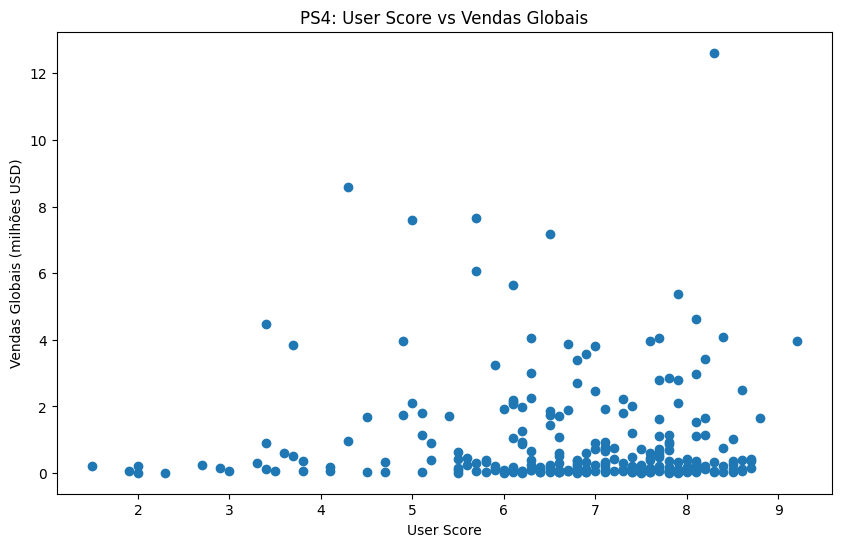

In [190]:
# Relação entre user_score e vendas globais

plt.figure(figsize=(10,6))

plt.scatter(
    ps4['user_score'],
    ps4['total_sales']
)

plt.title('PS4: User Score vs Vendas Globais')

plt.xlabel('User Score')
plt.ylabel('Vendas Globais (milhões USD)')

plt.show()

In [191]:
# Correlação entre user_score e vendas globais

ps4[['user_score', 'total_sales']].corr()

,user_score,total_sales
user_score,1.000000,-0.031957
total_sales,-0.031957,1.000000


Os gráficos de dispersão mostram que existe uma relação moderada positiva entre as avaliações dos críticos (`critic_score`) e as vendas globais dos jogos da plataforma PS4. O coeficiente de correlação encontrado foi aproximadamente 0,41, indicando que jogos com melhores avaliações da crítica tendem, em média, a apresentar vendas mais altas.

Por outro lado, a relação entre as avaliações dos usuários (`user_score`) e as vendas globais mostrou-se praticamente inexistente. O coeficiente de correlação encontrado foi aproximadamente -0,03, valor muito próximo de zero, indicando ausência de correlação significativa entre essas variáveis.

Esses resultados sugerem que as avaliações dos críticos possuem maior influência no desempenho comercial dos jogos do que as avaliações dos usuários. Além disso, observa-se que alguns jogos alcançam vendas muito elevadas mesmo sem concentrarem notas extremamente altas dos usuários, evidenciando que outros fatores, como marketing, franquias populares e exclusividade de plataforma, também influenciam fortemente as vendas.

<div class="alert alert-block alert-success">
<b> Comentário do revisor: </b> <a class="tocSkip"></a>

A correlação entre score e vendas foi analisada!
</div>

### Distribuição de vendas por gênero

Agora será analisada a distribuição das vendas globais por gênero de jogos. O objetivo é identificar quais gêneros apresentam maior potencial comercial e compreender padrões de desempenho no mercado.

In [192]:
# Vendas globais por gênero

genre_sales = (
    recent_df.groupby('genre')['total_sales']
    .sum()
    .sort_values(ascending=False)
)

genre_sales

genre
Action          441.12
Shooter         304.73
Role-Playing    192.80
Sports          181.07
Misc             85.04
Platform         61.00
Racing           53.50
Fighting         44.49
Simulation       35.12
Adventure        29.43
Strategy         13.34
Puzzle            4.89
Name: total_sales, dtype: float64

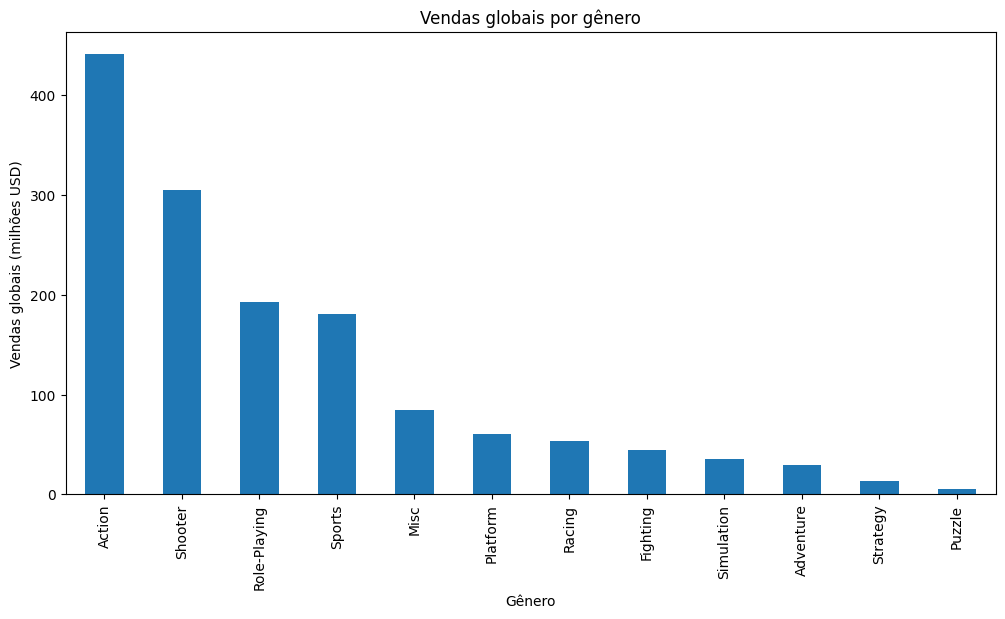

In [193]:
# Gráfico de vendas globais por gênero

genre_sales.plot(
    kind='bar',
    figsize=(12,6)
)

plt.title('Vendas globais por gênero')
plt.xlabel('Gênero')
plt.ylabel('Vendas globais (milhões USD)')

plt.show()

Observa-se que os gêneros Action e Shooter lideram as vendas globais no período analisado, indicando forte preferência dos consumidores por jogos com maior intensidade, ação e competitividade. O gênero Action apresenta o maior volume de vendas entre todos os gêneros, destacando sua ampla popularidade no mercado.

Os gêneros Role-Playing e Sports também apresentam desempenho bastante relevante, demonstrando que jogos de RPG e esportes possuem forte participação nas vendas globais.

Por outro lado, gêneros como Puzzle, Strategy e Adventure apresentam volumes de vendas significativamente menores, indicando um público mais específico e menor potencial comercial em comparação aos gêneros mais populares.

De maneira geral, os dados sugerem que gêneros com gameplay mais dinâmico, competitivo ou focado em ação tendem a alcançar maiores volumes de vendas globais.

<div class="alert alert-block alert-success">
<b> Comentário do revisor: </b> <a class="tocSkip"></a>
    
- As distribuições de vendas por plataforma e por gênero foram analisadas
- A conclusão foi apresentada
</div>

# Perfil de usuário por região

Nesta etapa, analisarei o comportamento dos consumidores em diferentes regiões do mundo. O objetivo é identificar preferências regionais relacionadas às plataformas, gêneros e classificações ESRB dos jogos.

### Plataformas mais populares por região

Primeiramente, serão identificadas as plataformas com maiores vendas nas regiões da América do Norte (NA), Europa (EU) e Japão (JP).

In [194]:
# Top plataformas na América do Norte

na_platforms = (
    recent_df.groupby('platform')['na_sales']
    .sum()
    .sort_values(ascending=False)
    .head(5)
)

na_platforms

platform
X360    140.05
PS4     108.74
PS3     103.38
XOne     93.12
3DS      55.31
Name: na_sales, dtype: float64

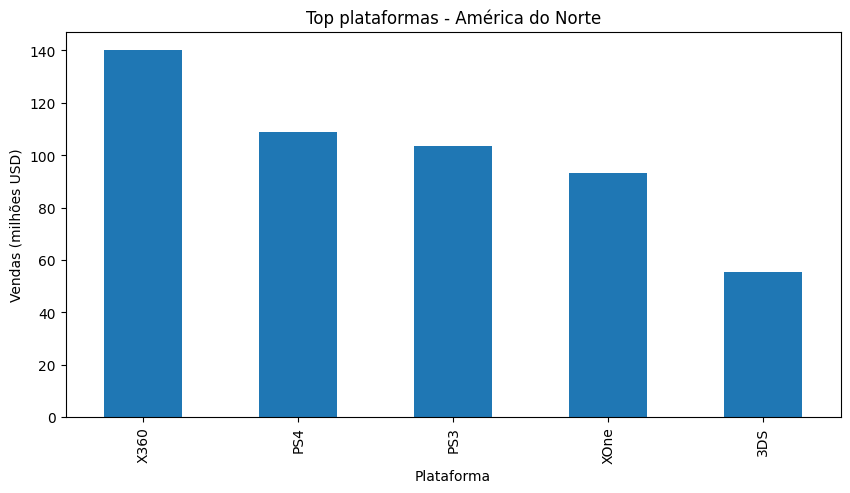

In [195]:
na_platforms.plot(
    kind='bar',
    figsize=(10,5)
)

plt.title('Top plataformas - América do Norte')
plt.xlabel('Plataforma')
plt.ylabel('Vendas (milhões USD)')

plt.show()

In [196]:
# Top plataformas na Europa

eu_platforms = (
    recent_df.groupby('platform')['eu_sales']
    .sum()
    .sort_values(ascending=False)
    .head(5)
)

eu_platforms

platform
PS4     141.09
PS3     106.86
X360     74.52
XOne     51.59
3DS      42.64
Name: eu_sales, dtype: float64

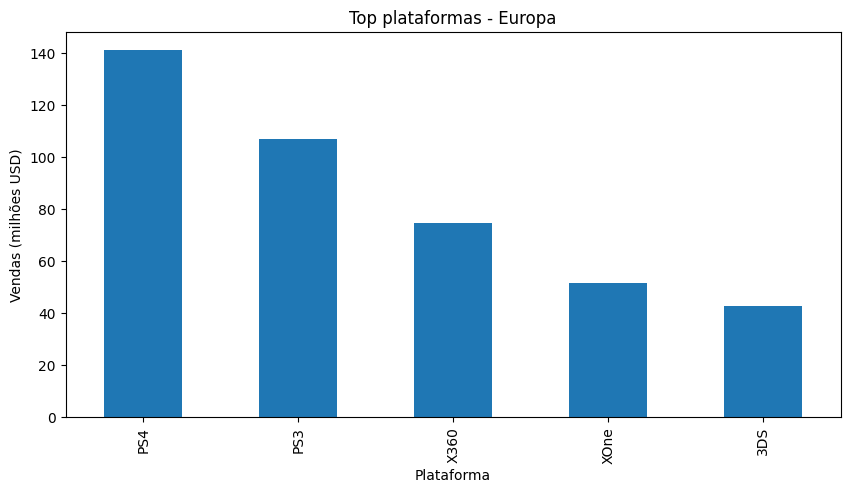

In [197]:
eu_platforms.plot(
    kind='bar',
    figsize=(10,5)
)

plt.title('Top plataformas - Europa')
plt.xlabel('Plataforma')
plt.ylabel('Vendas (milhões USD)')

plt.show()

In [198]:
# Top plataformas no Japão

jp_platforms = (
    recent_df.groupby('platform')['jp_sales']
    .sum()
    .sort_values(ascending=False)
    .head(5)
)

jp_platforms

platform
3DS     87.79
PS3     35.29
PSV     21.04
PS4     15.96
WiiU    13.01
Name: jp_sales, dtype: float64

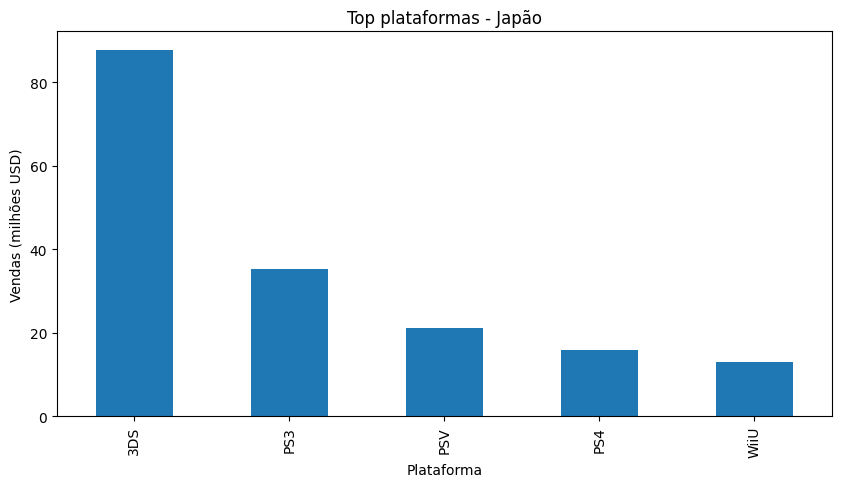

In [199]:
jp_platforms.plot(
    kind='bar',
    figsize=(10,5)
)

plt.title('Top plataformas - Japão')
plt.xlabel('Plataforma')
plt.ylabel('Vendas (milhões USD)')

plt.show()

Os gráficos mostram diferenças importantes nas preferências de plataformas entre as regiões analisadas.

Na América do Norte, observa-se forte predominância das plataformas da Sony e Microsoft, com destaque para PS4, PS3 e Xbox 360. Isso demonstra grande popularidade dos consoles domésticos tradicionais no mercado norte-americano.

Na Europa, o comportamento é bastante semelhante ao da América do Norte, com liderança do PS4 e PS3, seguidos pelo Xbox 360. Isso indica uma forte presença das plataformas PlayStation no mercado europeu, além de boa participação da Microsoft.

Já no Japão, percebe-se um perfil bastante diferente. O Nintendo 3DS lidera de forma significativa as vendas, seguido pelo PS3 e PSV. Isso sugere uma preferência maior dos consumidores japoneses por consoles portáteis e plataformas desenvolvidas por empresas japonesas.

Além disso, observa-se que plataformas muito populares no Ocidente, como Xbox 360 e Xbox One, possuem participação reduzida no mercado japonês, evidenciando diferenças culturais e de preferência entre as regiões.

De modo geral, os dados mostram que o perfil do consumidor varia significativamente entre os mercados, sendo essencial considerar essas diferenças regionais no planejamento de campanhas publicitárias e estratégias de vendas.

### Gêneros mais populares por região

Agora serão analisados os gêneros de jogos mais populares em cada região. Essa análise permitirá compreender diferenças culturais e preferências específicas dos consumidores da América do Norte, Europa e Japão.

In [200]:
# Top gêneros na América do Norte

na_genres = (
    recent_df.groupby('genre')['na_sales']
    .sum()
    .sort_values(ascending=False)
    .head(5)
)

na_genres

genre
Action          177.84
Shooter         144.77
Sports           81.53
Role-Playing     64.00
Misc             38.19
Name: na_sales, dtype: float64

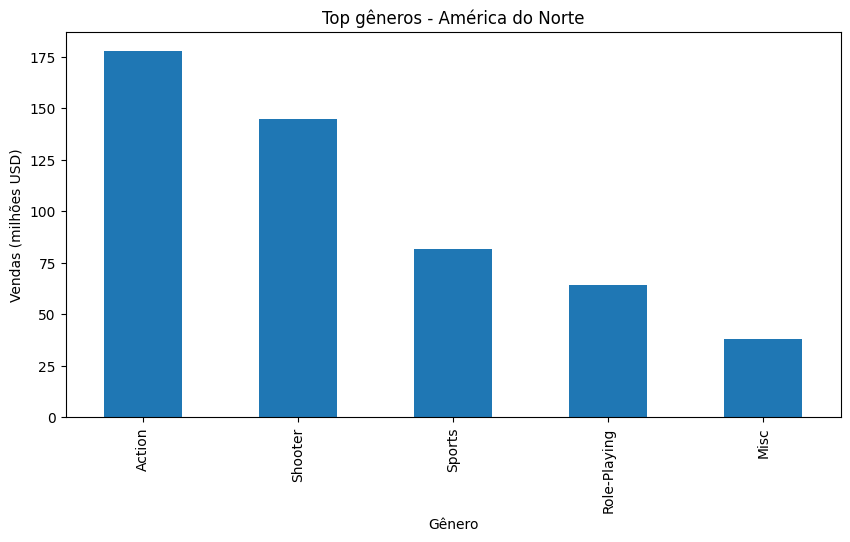

In [201]:
na_genres.plot(
    kind='bar',
    figsize=(10,5)
)

plt.title('Top gêneros - América do Norte')
plt.xlabel('Gênero')
plt.ylabel('Vendas (milhões USD)')

plt.show()

In [202]:
# Top gêneros na Europa

eu_genres = (
    recent_df.groupby('genre')['eu_sales']
    .sum()
    .sort_values(ascending=False)
    .head(5)
)

eu_genres

genre
Action          159.34
Shooter         113.47
Sports           69.09
Role-Playing     48.53
Racing           27.29
Name: eu_sales, dtype: float64

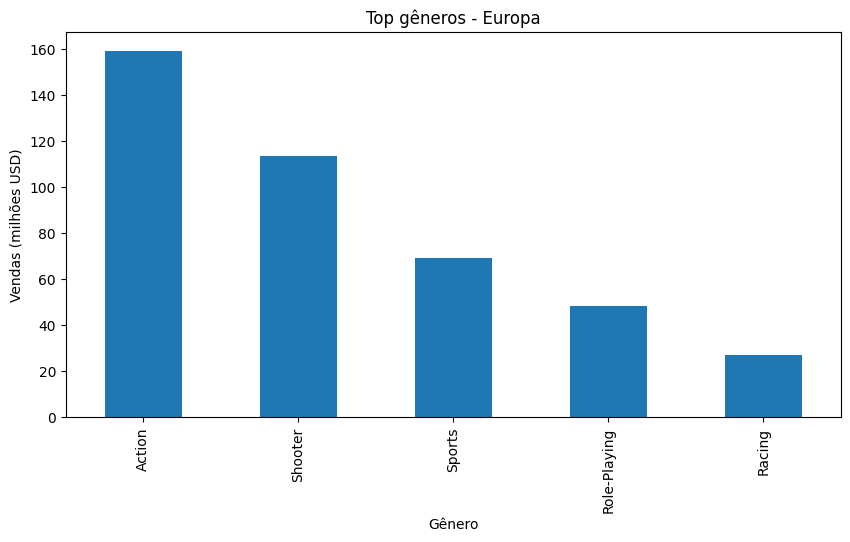

In [203]:
eu_genres.plot(
    kind='bar',
    figsize=(10,5)
)

plt.title('Top gêneros - Europa')
plt.xlabel('Gênero')
plt.ylabel('Vendas (milhões USD)')

plt.show()

In [204]:
# Top gêneros no Japão

jp_genres = (
    recent_df.groupby('genre')['jp_sales']
    .sum()
    .sort_values(ascending=False)
    .head(5)
)

jp_genres

genre
Role-Playing    65.44
Action          52.80
Misc            12.86
Simulation      10.41
Fighting         9.44
Name: jp_sales, dtype: float64

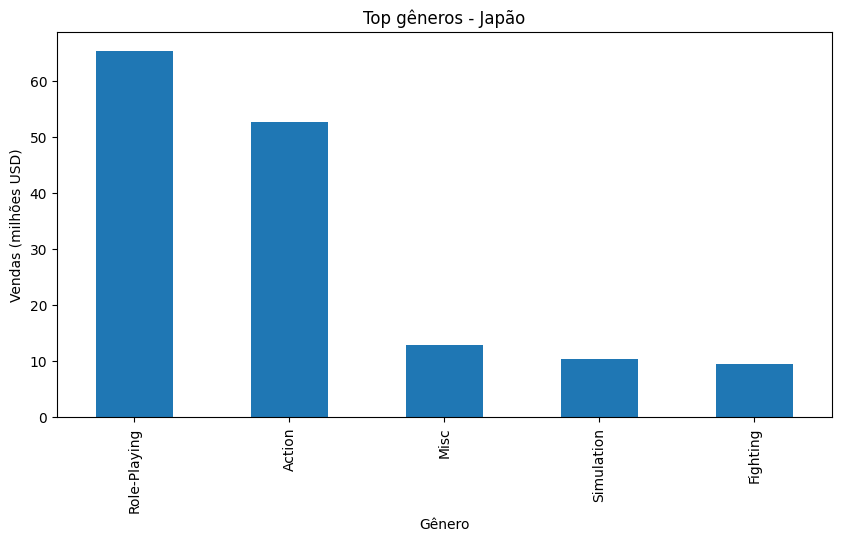

In [205]:
jp_genres.plot(
    kind='bar',
    figsize=(10,5)
)

plt.title('Top gêneros - Japão')
plt.xlabel('Gênero')
plt.ylabel('Vendas (milhões USD)')

plt.show()

Os gráficos mostram diferenças interessantes nas preferências de gêneros entre as regiões analisadas.

Na América do Norte e na Europa, os gêneros Action e Shooter lideram as vendas de forma bastante significativa. Isso indica forte preferência dos consumidores ocidentais por jogos de ação, combate e competitividade. O gênero Sports também apresenta boa participação nessas regiões, demonstrando popularidade dos jogos esportivos nesses mercados.

Já no Japão, observa-se um comportamento bastante diferente. O gênero Role-Playing (RPG) lidera as vendas com ampla vantagem, seguido pelo gênero Action. Isso evidencia a forte tradição do mercado japonês em jogos de RPG, especialmente franquias desenvolvidas por empresas japonesas.

Além disso, gêneros como Fighting e Simulation aparecem entre os mais populares no Japão, enquanto possuem menor destaque na América do Norte e Europa.

De maneira geral, os dados mostram que as preferências de gênero variam significativamente entre as regiões. Enquanto os mercados ocidentais demonstram maior interesse por jogos de ação e tiro, o mercado japonês apresenta forte preferência por RPGs e gêneros tradicionalmente populares na cultura gamer japonesa.

### Influência da classificação ESRB nas vendas regionais

Nesta etapa, será analisado se as classificações ESRB influenciam as vendas de jogos nas diferentes regiões. Essa análise permitirá verificar se determinadas faixas etárias possuem maior impacto comercial em mercados específicos.

In [206]:

# Vendas por classificação ESRB na América do Norte


na_rating = (
    recent_df.groupby('rating')['na_sales']
    .sum()
    .sort_values(ascending=False)
)

na_rating

rating
M       231.57
E       114.37
E10+     75.70
T        66.02
Name: na_sales, dtype: float64

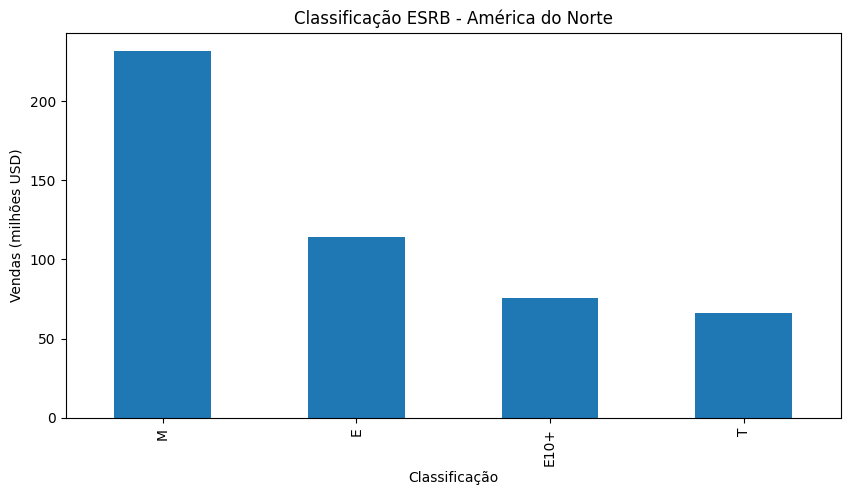

In [207]:
na_rating.plot(
    kind='bar',
    figsize=(10,5)
)

plt.title('Classificação ESRB - América do Norte')
plt.xlabel('Classificação')
plt.ylabel('Vendas (milhões USD)')

plt.show()

In [208]:
# Vendas por classificação ESRB na Europa

eu_rating = (
    recent_df.groupby('rating')['eu_sales']
    .sum()
    .sort_values(ascending=False)
)

eu_rating

rating
M       193.96
E       113.03
E10+     55.37
T        52.96
Name: eu_sales, dtype: float64

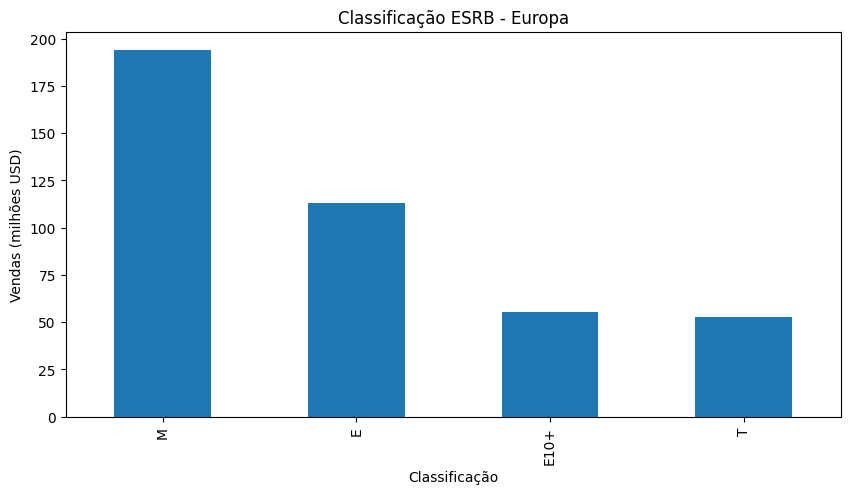

In [209]:
eu_rating.plot(
    kind='bar',
    figsize=(10,5)
)

plt.title('Classificação ESRB - Europa')
plt.xlabel('Classificação')
plt.ylabel('Vendas (milhões USD)')

plt.show()

In [210]:
# Vendas por classificação ESRB no Japão

jp_rating = (
    recent_df.groupby('rating')['jp_sales']
    .sum()
    .sort_values(ascending=False)
)

jp_rating

rating
E       28.33
T       26.02
M       21.20
E10+     8.19
Name: jp_sales, dtype: float64

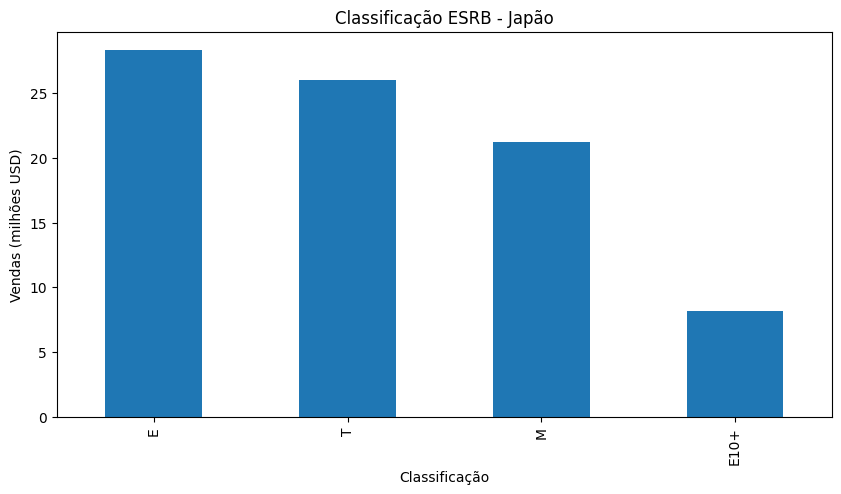

In [211]:
jp_rating.plot(
    kind='bar',
    figsize=(10,5)
)

plt.title('Classificação ESRB - Japão')
plt.xlabel('Classificação')
plt.ylabel('Vendas (milhões USD)')

plt.show()

Os gráficos mostram que as classificações ESRB influenciam as vendas de maneira diferente entre as regiões analisadas.

Na América do Norte e na Europa, os jogos classificados como "M" (Mature — para maiores de 17 anos) lideram as vendas de forma significativa. Isso indica forte popularidade de jogos com conteúdo mais adulto nesses mercados, especialmente títulos de ação, tiro e combate.

As classificações "E" (Everyone — para todos) e "T" (Teen — adolescentes) também apresentam participação relevante nas vendas dessas regiões, mostrando que jogos voltados para públicos mais amplos continuam tendo forte presença no mercado.

Já no Japão, observa-se um perfil diferente. Os jogos classificados como "E" e "T" apresentam maior volume de vendas, enquanto os jogos classificados como "M" possuem desempenho mais moderado. Isso sugere uma preferência maior do mercado japonês por jogos com conteúdo menos voltado para violência intensa ou temática adulta.

De maneira geral, os dados indicam que as preferências relacionadas à classificação etária variam conforme a região, reforçando a importância de adaptar estratégias de marketing e distribuição de jogos para diferentes mercados consumidores.

<div class="alert alert-block alert-warning">
<b> Comentário do revisor: </b> <a class="tocSkip"></a>

- O perfil de usuário foi criado por região. Sugestão: aqui você poderia calcular outras estatísticas descritivas como **desvio padrão** de vendas por região
</div>

# Teste de hipóteses

Nesta etapa, serão realizados testes estatísticos para verificar hipóteses relacionadas às avaliações dos usuários em diferentes plataformas e gêneros de jogos.

Será utilizado o teste t de Student para comparação entre médias, adotando um nível de significância de 5% (`alpha = 0.05`).

### Hipótese 1

Hipótese nula (H0): As médias das avaliações dos usuários das plataformas Xbox One e PC são iguais.

Hipótese alternativa (H1): As médias das avaliações dos usuários das plataformas Xbox One e PC são diferentes.

In [212]:
# Filtrando avaliações de usuários para Xbox One e PC

xone = recent_df[
    recent_df['platform'] == 'XOne'
]['user_score'].dropna()

pc = recent_df[
    recent_df['platform'] == 'PC'
]['user_score'].dropna()

In [213]:
# Definindo nível de significância

alpha = 0.05

In [214]:
# Teste de hipótese

results = stats.ttest_ind(
    xone,
    pc,
    equal_var=False
)

print('p-value:', results.pvalue)

p-value: 0.5489537965134912


In [215]:
# Resultado do teste

if results.pvalue < alpha:
    print("Rejeitamos a hipótese nula")
else:
    print("Não rejeitamos a hipótese nula")

Não rejeitamos a hipótese nula


O valor de p encontrado foi aproximadamente 0,55, valor superior ao nível de significância adotado (`alpha = 0.05`).

Dessa forma, não há evidências estatísticas suficientes para rejeitar a hipótese nula. Isso indica que as médias das avaliações dos usuários das plataformas Xbox One e PC podem ser consideradas estatisticamente semelhantes no período analisado.

### Hipótese 2

Hipótese nula (H0): As médias das avaliações dos usuários dos gêneros Action e Sports são iguais.

Hipótese alternativa (H1): As médias das avaliações dos usuários dos gêneros Action e Sports são diferentes.

In [216]:
# Filtrando avaliações dos gêneros Action e Sports

action = recent_df[
    recent_df['genre'] == 'Action'
]['user_score'].dropna()

sports = recent_df[
    recent_df['genre'] == 'Sports'
]['user_score'].dropna()

In [217]:
# Teste de hipótese

results = stats.ttest_ind(
    action,
    sports,
    equal_var=False
)

print('p-value:', results.pvalue)

p-value: 4.24307776572644e-20


In [218]:
# Resultado do teste

if results.pvalue < alpha:
    print("Rejeitamos a hipótese nula")
else:
    print("Não rejeitamos a hipótese nula")

Rejeitamos a hipótese nula


O valor de p encontrado foi extremamente pequeno (`p-value < 0.05`), sendo muito inferior ao nível de significância adotado.

Dessa forma, rejeitamos a hipótese nula. Isso indica que existe diferença estatisticamente significativa entre as médias das avaliações dos usuários dos gêneros Action e Sports.

Os resultados sugerem que os usuários avaliam esses dois gêneros de maneira diferente, evidenciando diferenças de percepção e experiência entre os tipos de jogos analisados.

<div class="alert alert-block alert-success">
<b> Comentário do revisor: </b> <a class="tocSkip"></a>

Bom trabalho com os testes de hipótese acima:
- As hipóteses nula e alternativa foram definidas
- O teste foi executado corretamente
- O `p-value` foi exibido.
</div>

# Conclusão geral

Com base nas análises realizadas, foi possível identificar padrões importantes relacionados ao mercado global de jogos eletrônicos.

Observou-se que as plataformas possuem ciclos de vida relativamente curtos, normalmente entre 8 e 10 anos, reforçando a importância de utilizar dados recentes para análises de mercado. Entre as plataformas mais promissoras para o período analisado destacam-se PS4 e Xbox One, que apresentaram forte desempenho em vendas globais e grande relevância para campanhas voltadas ao mercado de 2017.

Os gêneros Action e Shooter mostraram-se os mais lucrativos na América do Norte e Europa, enquanto o mercado japonês apresentou maior preferência por jogos do gênero Role-Playing (RPG). Isso demonstra diferenças culturais significativas entre as regiões analisadas e evidencia a necessidade de estratégias de marketing adaptadas para cada público consumidor.

Também foi observado que avaliações dos críticos possuem relação moderada com as vendas globais dos jogos, enquanto as avaliações dos usuários apresentaram pouca influência direta no desempenho comercial. Esse resultado sugere que campanhas envolvendo divulgação especializada, acesso antecipado para críticos e fortalecimento da reputação dos jogos antes do lançamento podem impactar positivamente as vendas.

As análises regionais mostraram ainda que as preferências de plataformas, gêneros e classificações ESRB variam consideravelmente entre América do Norte, Europa e Japão. Na América do Norte e Europa, jogos de ação e tiro voltados para públicos mais maduros apresentaram maior popularidade, enquanto o Japão demonstrou preferência maior por RPGs e jogos com classificações menos voltadas para conteúdo adulto.

Nos testes de hipóteses, não foram encontradas diferenças estatisticamente significativas entre as médias das avaliações dos usuários das plataformas Xbox One e PC. Por outro lado, foi identificada diferença significativa entre as avaliações dos gêneros Action e Sports, indicando percepções diferentes dos usuários em relação a esses estilos de jogos.

Com base nesses resultados, recomenda-se que campanhas publicitárias priorizem plataformas mais recentes e mercados regionais específicos, direcionando investimentos para os gêneros mais populares em cada região. Estratégias segmentadas, associadas a divulgação especializada e foco em plataformas em crescimento, podem aumentar significativamente as chances de sucesso comercial dos jogos no mercado de 2017.